### Фокин Никита 5130901/30201

## Упражнения к главе 8

### Упражнение 8.2

В ходе выполнения этого задания было исследовано, что происходит с БПФ при увеличении среднеквадратичного отклонения гауссовой кривой

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
from thinkdsp import decorate

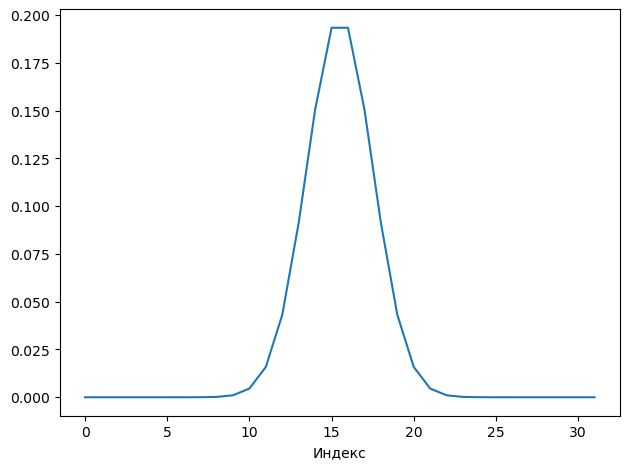

In [6]:
gaussian = scipy.signal.windows.gaussian(M=32, std=2)
gaussian /= sum(gaussian)
plt.plot(gaussian)
decorate(xlabel='Индекс')

Выведем FFT для этого сигнала:

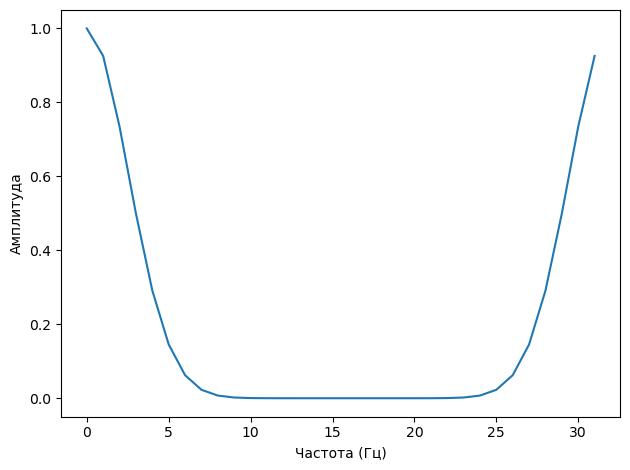

In [8]:
fft_gaussian = np.fft.fft(gaussian)
plt.plot(abs(fft_gaussian))
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

Сместим график влево, чтобы получить вид графика гауссовой фунции:

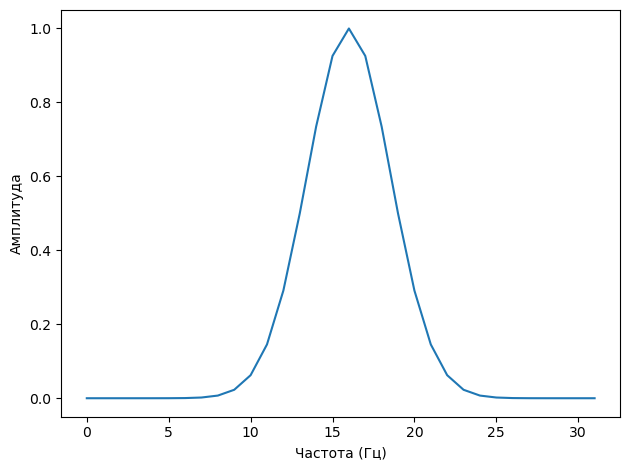

In [10]:
N = len(gaussian)
fft_rolled = np.roll(fft_gaussian, N//2)
plt.plot(abs(fft_rolled))
decorate(xlabel='Частота (Гц)', ylabel='Амплитуда')

Функция, строящая гауссову кривую и его быстрое преобразование Фурье:

In [18]:
def plot_gaussian(std):
    M = 32
    gaussian = scipy.signal.windows.gaussian(M=M, std=std)
    gaussian /= sum(gaussian)
    
    plt.subplot(1, 2, 1)
    plt.plot(gaussian)
    decorate(xlabel='Время')

    fft_gaussian = np.fft.fft(gaussian)
    fft_rolled = np.roll(fft_gaussian, M//2)
    
    plt.subplot(1, 2, 2)
    plt.plot(np.abs(fft_rolled))
    decorate(xlabel='Частота')
    plt.show()

In [ ]:
from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets

slider = widgets.FloatSlider(min=0.1, max=10, value=2)
interact(plot_gaussian, std=slider);

interactive(children=(FloatSlider(value=2.0, description='std', max=10.0, min=0.1), Output()), _dom_classes=('…

Таким образом по мере увеличения стандартного отклонения гауссова функция становится шире, а её БПФ - уже.

### Упражнение 8.3

Рассмотрим односекундную волну с частотой 100 кГц

In [29]:
from thinkdsp import SquareSignal

signal = SquareSignal(freq=440)
wave = signal.make_wave(duration=1.0, framerate=100000)

Создадим несколько окон:

In [39]:
M = 15
std = 2.5

gaussian = scipy.signal.windows.gaussian(M=M, std=std)   
bartlett = np.bartlett(M)
blackman = np.blackman(M)
hamming = np.hamming(M)
hanning = np.hanning(M)

windows = [blackman, gaussian, hanning, hamming]
names = ['блэкман', 'гаусс', 'ханнинг', 'хэмминг']

for window in windows:
    window /= sum(window)

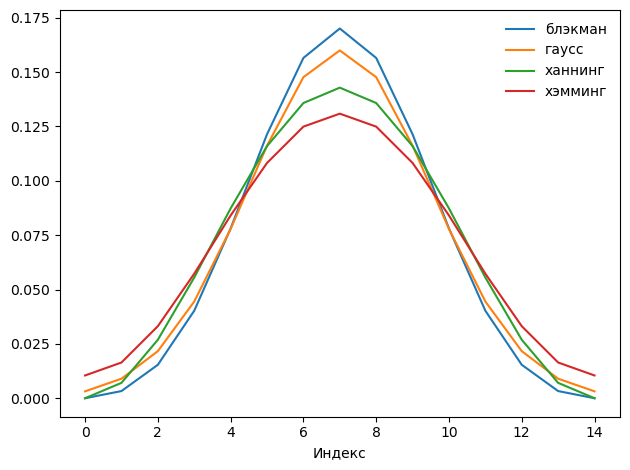

In [40]:
for window, name in zip(windows, names):
    plt.plot(window, label=name)

decorate(xlabel='Индекс')

Построим их ДПФ:

In [41]:
def zero_pad(array, n):
    res = np.zeros(n)
    res[:len(array)] = array
    return res

def plot_window_dfts(windows, names):
    for window, name in zip(windows, names):
        padded =  zero_pad(window, len(wave))
        dft_window = np.fft.rfft(padded)
        plt.plot(abs(dft_window), label=name)

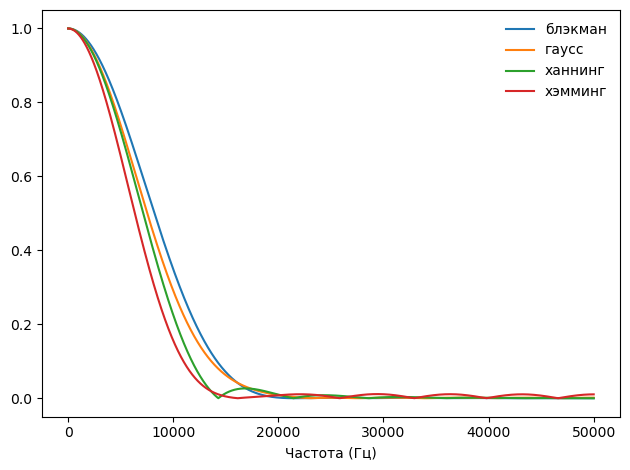

In [42]:
plot_window_dfts(windows, names)
decorate(xlabel='Частота (Гц)')

Теперь с логарифмической шкалой:

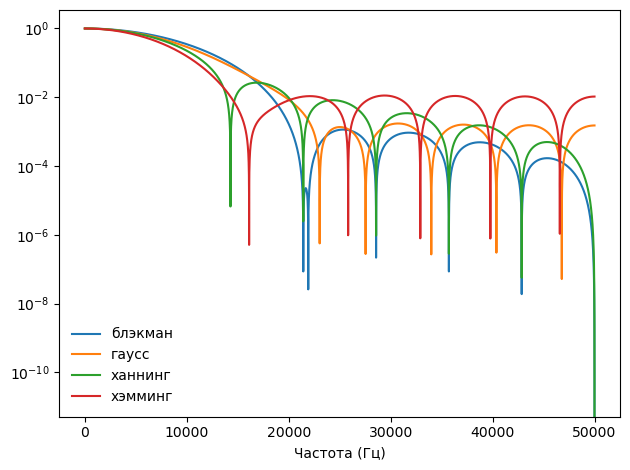

In [43]:
plot_window_dfts(windows, names)
decorate(xlabel='Частота (Гц)', yscale='log')

На логарифмической шкале видно, что окна Хэмминга и Ханнинга сначала затухают быстрее, чем другие. Окна Хэмминга и Гаусса имеют наиболее устойчивые боковые лепестки.